# Cuaderno 4: Regla de Oja

En este cuaderno probaremos algunas reglas de plasticidad sináptica y sus consecuencias estadísticas.

## Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

### Funciones de graficado

In [2]:
def visualizar_red(x, w):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
  ax1.plot(x, label=["Neurona pre-sináptica 1", "Neurona pre-sináptica 2"])
  ax1.plot(x @ w, label="Neurona post-sináptica")
  ax1.set_xlabel("Tiempo (s)")
  ax1.set_ylabel("Frecuencia (Hz)")
  ax1.legend()

  # Graficamos los puntos
  z = x - np.mean(x, axis=0)
  ax2.scatter(z[:, 0], z[:, 1])
  ax2.arrow(0, 0, w[0].item(), w[1].item(), width=0.01)
  ax2.set_xlabel("Neurona pre-sináptica 1")
  ax2.set_ylabel("Neurona pre-sináptica 2")

  plt.show()

def visualizar_vector(v):
  """ Dibuja un vector 2D

  Argumentos:
    v (ndarray): array de tamaño (2,) con las coordenadas del vector
  """
  fig, ax = plt.subplots()

  # Set up plot aesthetics
  ax.spines['top'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.set(xlim = [-6, 6], ylim = [-6, 6])
  ax.grid(True, alpha=.4)

  # Plot vectors
  v_arr = ax.arrow(0, 0, v[0], v[1], color='black', width=0.08, length_includes_head=True)
  ax.set(xlim = [-4, 4], ylim = [-4, 4])

## Introducción a vectores

Consideremos primero un vector $\pmb{a}$ definido como:

$$ \pmb{a} = \begin{bmatrix} a_{1} \\ a_{2} \end{bmatrix} $$

Un vector se puede considerar desde al menos dos perspectivas: como una lista ordenada de números o como una flecha con la base en el origen de un sistema de coordenadas. Son dos maneras de mirar lo mismo: en el caso de la flecha, la punta está definida por una coordenada (que puede representarse con la lista ordenada).

La **dimensionalidad** de un vector está determinada por la cantidad de componentes en la lista ordenada (o por la dimensionalidad del espacio en el que existe la flecha). Decimos, entonces, que este vector de dos dimensiones tiene 2 componentes: $a_1$ y $a_2$.

Veamos como inicializar y visualizar un vector arbitrario en Numpy.

In [3]:
a = np.array([2, 1])
print(a)

[2 1]


Cuando lo imprimimos, un vector no parece ser otra cosa que una lista ordenada. Generalmente, es mejor visualizarlo como una flecha en un espacio n-dimensional. Ejecutá la celda siguiente para visualizar este vector en un espacio de dos dimensiones:

In [4]:
@widgets.interact(a1=widgets.IntSlider(2, -4, 4, description="$a_{1}$"), a2=widgets.IntSlider(1, -4, 4, description="$a_{2}$"))
def interactive(a1, a2=1):
  visualizar_vector(np.array([a1, a2]))

interactive(children=(IntSlider(value=2, description='$a_{1}$', max=4, min=-4), IntSlider(value=1, description…

## Aprendizaje Hebbiano

In [5]:
def generar_estimulo(
    n=64,
    n_frames=500,
    dt=0.015,
    velocidad=10.0,
    semilla=None
):
    """
    Genera un estímulo visual naturalístico con correlaciones
    espacio-temporales de largo alcance.

    El estímulo se construye en el dominio de Fourier. La potencia espacial
    decrece aproximadamente como 1/k^2, de modo que las frecuencias
    espaciales bajas tienen mayor amplitud que las altas. Además, cada
    componente espacial evoluciona temporalmente con una constante de tiempo
    dependiente de su frecuencia.

    Esta implementación es una aproximación didáctica inspirada en el
    estímulo naturalístico utilizado por Pitkow y Meister (2012).

    Parameters
    ----------
    n : int, default=64
        Tamaño espacial de cada frame. Cada imagen generada tendrá dimensiones
        ``(n, n)``.

    n_frames : int, default=500
        Número total de frames del estímulo.

    dt : float, default=0.015
        Duración de cada frame, en segundos.

    velocidad : float, default=10.0
        Parámetro que controla la relación entre frecuencia espacial y
        correlación temporal. Valores mayores hacen que las componentes
        espaciales cambien más rápidamente.

    semilla : int or None, default=None
        Semilla para el generador de números aleatorios. Si es ``None``,
        se utiliza un estado aleatorio diferente en cada ejecución.

    Returns
    -------
    estimulo : ndarray of shape (n_frames, n, n)
        Secuencia de frames del estímulo. Cada frame está normalizado para
        tener aproximadamente media cero y desviación estándar uno.

    Notes
    -----
    Para una frecuencia espacial de magnitud ``k``, la potencia espacial se
    define aproximadamente como

    ``P(k) ∝ 1 / k^2``.

    La constante de tiempo de cada componente espacial se define como

    ``tau(k) = 1 / (k * velocidad)``.

    Esto hace que las estructuras espaciales grandes, correspondientes a
    frecuencias bajas, varíen más lentamente que los detalles espaciales
    pequeños.

    La componente de frecuencia espacial cero se elimina para evitar que la
    luminancia media global domine el estímulo.
    """
    rng = np.random.default_rng(semilla)

    # Frecuencias espaciales
    kx = np.fft.fftfreq(n)
    ky = np.fft.fftfreq(n)

    KX, KY = np.meshgrid(kx, ky)

    # Magnitud de la frecuencia espacial
    K = np.sqrt(KX**2 + KY**2)

    # Versión segura para evitar divisiones por cero
    K_safe = K.copy()
    K_safe[0, 0] = 1.0

    # Espectro de potencia espacial ~ 1/k²
    potencia = 1 / K_safe**2
    potencia[0, 0] = 0.0

    # Constante de tiempo dependiente de la frecuencia espacial
    tau = 1 / (K_safe * velocidad)

    # Correlación temporal entre frames consecutivos
    alpha = np.exp(-dt / tau)
    alpha[0, 0] = 0.0

    # Estado inicial en el dominio de Fourier
    F = np.zeros((n, n), dtype=complex)

    estimulo = np.zeros((n_frames, n, n))

    for t in range(n_frames):

        # Ruido gaussiano complejo
        ruido = (
            rng.standard_normal((n, n))
            + 1j * rng.standard_normal((n, n))
        )

        # Ajustar la amplitud de cada frecuencia espacial
        objetivo = ruido * np.sqrt(potencia)

        # Evolución temporal correlacionada
        F = (
            alpha * F
            + np.sqrt(1 - alpha**2) * objetivo
        )

        # Volver al dominio espacial
        frame = np.fft.ifft2(F).real

        # Normalización del contraste
        std = frame.std()

        if std > 0:
            frame = (frame - frame.mean()) / std
        else:
            frame = frame - frame.mean()

        estimulo[t] = frame

    return estimulo

def campo_receptivo(
    n,
    centro,
    sigma_center=2,
    sigma_surround=5,
    alpha=0.8
):
    """
    Genera un campo receptivo bidimensional tipo center-surround mediante
    una diferencia de gaussianas (Difference of Gaussians, DoG).

    El campo receptivo se construye como la diferencia entre una gaussiana
    central angosta y positiva, y una gaussiana periférica más amplia y
    ponderada negativamente.

    Parameters
    ----------
    n : int
        Tamaño espacial del campo receptivo. La salida tendrá dimensiones
        ``(n, n)``.

    centro : tuple of int
        Coordenadas ``(fila, columna)`` del centro del campo receptivo.

    sigma_center : float, default=2
        Desviación estándar de la gaussiana central, en píxeles.

    sigma_surround : float, default=5
        Desviación estándar de la gaussiana periférica, en píxeles.

    alpha : float, default=0.8
        Peso relativo del componente surround. Valores mayores aumentan la
        contribución inhibitoria de la periferia.

    Returns
    -------
    rf : ndarray of shape (n, n)
        Campo receptivo center-surround. Los valores positivos corresponden
        al centro excitatorio y los negativos al surround inhibitorio.

    Notes
    -----
    El campo receptivo se define como

    ``RF(x, y) = G_center(x, y) - alpha * G_surround(x, y)``

    donde ambas gaussianas están centradas en la misma posición y se
    normalizan por separado para que su suma sea 1.

    Esta implementación representa una célula ON-center. Una célula
    OFF-center puede obtenerse invirtiendo el signo del campo receptivo.
    """
    y0, x0 = centro

    y, x = np.mgrid[0:n, 0:n]

    g_center = np.exp(
        -((x - x0)**2 + (y - y0)**2)
        / (2 * sigma_center**2)
    )

    g_surround = np.exp(
        -((x - x0)**2 + (y - y0)**2)
        / (2 * sigma_surround**2)
    )

    g_center /= g_center.sum()
    g_surround /= g_surround.sum()

    rf = g_center - alpha * g_surround

    return rf

def respuesta_a_firing_rate(respuesta, tasa_max=50, ganancia=5, umbral=0):
    """
    Convierte la respuesta lineal de un campo receptivo en firing rate
    mediante una función sigmoide.

    Parameters
    ----------
    respuesta : float or ndarray
        Respuesta lineal del campo receptivo.

    tasa_max : float, default=50
        Tasa máxima de disparo, en Hz.

    ganancia : float, default=5
        Pendiente de la función sigmoide.

    umbral : float, default=0
        Valor de la respuesta lineal correspondiente al punto medio
        de la sigmoide.

    Returns
    -------
    firing_rate : float or ndarray
        Tasa de disparo, en Hz.
    """
    return tasa_max / (
        1 + np.exp(-ganancia * (respuesta - umbral))
    )

In [103]:
from matplotlib.patches import Circle
n = 500
movie = generar_estimulo(n_frames=n)
centro1 = (32, 28)
centro2 = (32, 30)
campo1 = campo_receptivo(n=64, centro=centro1)
campo2 = campo_receptivo(n=64, centro=centro2)
@widgets.interact(idx = (0, 99))
def visualizar_estimulos(idx):
    frame = movie[idx]
    fig, axes = plt.subplots(1, 3, figsize=(10, 6))
    axes[0].imshow(frame, cmap="gray")
    axes[0].add_patch(Circle(centro1[::-1], radius=3, fill=False, edgecolor="red", linewidth=2))
    axes[0].add_patch(Circle(centro2[::-1], radius=3, fill=False, edgecolor="blue", linewidth=2))
    axes[1].imshow(frame * campo1, cmap="gray", vmin=-0.05, vmax=0.05)
    axes[2].imshow(frame * campo2, cmap="gray", vmin=-0.05, vmax=0.05)
    plt.show()

interactive(children=(IntSlider(value=49, description='idx', max=99), Output()), _dom_classes=('widget-interac…

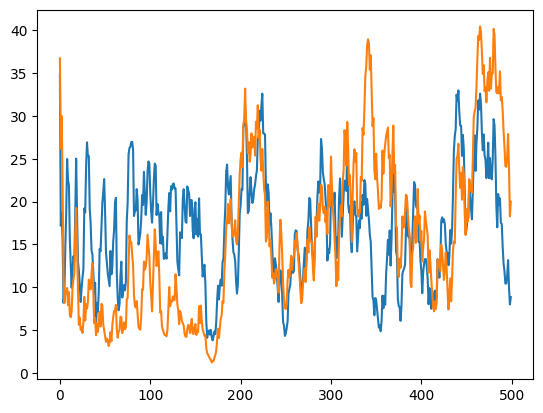

In [104]:
respuesta1 = np.sum(movie * campo1, axis=(1, 2))
respuesta2 = np.sum(movie * campo2, axis=(1, 2))
actividad1 = respuesta_a_firing_rate(respuesta1)
actividad2 = respuesta_a_firing_rate(respuesta2)

plt.plot(actividad1)
plt.plot(actividad2)
plt.show()

In [102]:
print("Respuesta lineal:", np.corrcoef(respuesta1, respuesta2)[0, 1])
print("Firing rate:", np.corrcoef(actividad1, actividad2)[0, 1])

Respuesta lineal: -0.09373483458736359
Firing rate: -0.11504032014231251


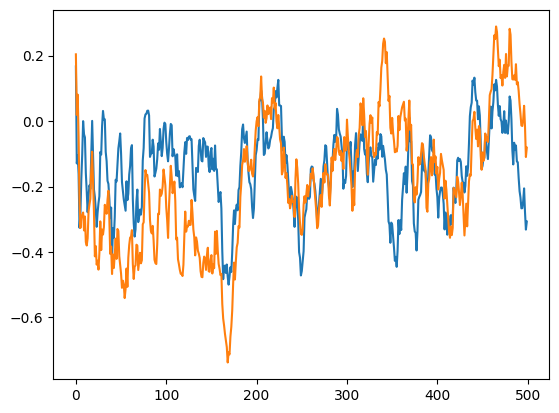

In [105]:
plt.plot(respuesta1)
plt.plot(respuesta2)
plt.show()

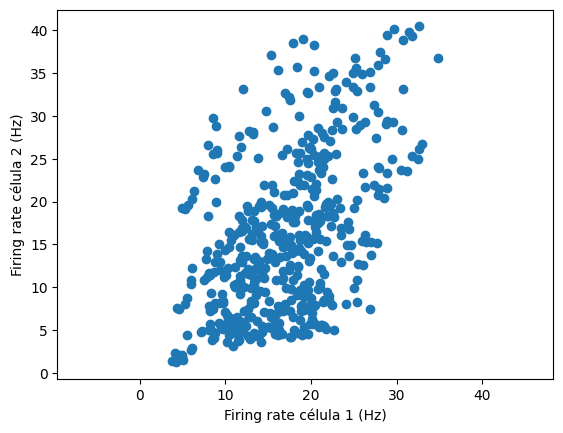

In [106]:
plt.scatter(actividad1, actividad2)

plt.xlabel("Firing rate célula 1 (Hz)")
plt.ylabel("Firing rate célula 2 (Hz)")
plt.axis('equal')
plt.show()

In [107]:
x = np.stack([actividad1, actividad2], axis=1)
w = np.array([-0.2, 0.5])
x @ w.T

array([ 1.13965715e+01,  9.64975218e+00,  1.12630015e+01,  7.86573910e+00,
        4.09533341e+00,  2.13053775e+00,  1.77265195e+00,  1.08495519e+00,
       -3.78190668e-02, -5.38989556e-01,  3.41649771e-01,  2.93185431e-01,
        7.08622177e-01,  1.58530282e+00,  2.59569907e+00,  2.73892946e+00,
        3.22109683e+00,  4.33871728e+00,  4.62642389e+00,  3.48752305e+00,
        2.34283970e+00,  4.24324377e-01,  1.16872072e+00,  8.50691053e-01,
        6.75727489e-01,  1.22043794e-01,  5.36371061e-01,  5.99696412e-01,
       -6.89151543e-01, -8.10744817e-01, -1.63232200e+00, -9.29282490e-01,
        3.72281969e-01,  1.26718225e+00,  1.36466861e+00,  2.90973431e+00,
        3.64218300e+00,  2.26955525e+00,  1.05477236e+00,  1.09997038e+00,
        1.10811910e+00,  1.25242987e+00,  9.60731430e-01,  9.93089575e-01,
        6.59850632e-01, -1.29490003e-01,  6.41619178e-01, -3.61495801e-02,
       -1.40913846e+00, -2.03238993e+00, -1.57403941e+00, -1.00927332e+00,
       -5.59549973e-01, -

In [108]:
@widgets.interact(w1=(-1, 1, 0.1), w2=(-1, 1, 0.1))
def simulate(w1 = -0.2, w2 = 0.5):
  w = np.array([w1, w2])
  visualizar_red(x, w)

interactive(children=(FloatSlider(value=-0.2, description='w1', max=1.0, min=-1.0), FloatSlider(value=0.5, des…

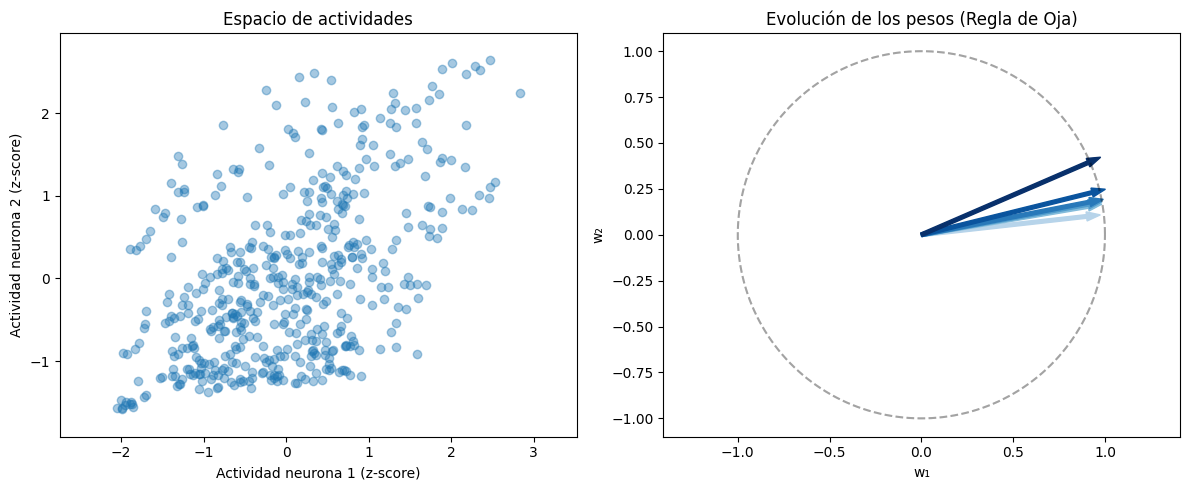

In [116]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel izquierdo: espacio de actividades ---
ax1.set_xlabel("Actividad neurona 1 (z-score)")
ax1.set_ylabel("Actividad neurona 2 (z-score)")
ax1.set_title("Espacio de actividades")
ax1.axis("equal")

# Dibujamos un círculo unitario de referencia
theta = np.linspace(0, 2 * np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2, label="Norma = 1")
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel("w₁")
ax2.set_ylabel("w₂")
ax2.set_title("Evolución de los pesos (Regla de Oja)")
ax2.axis("equal")

# Valor inicial de los pesos sinápticos
w = np.array([0.9, 0.1])

z = x - np.mean(x, axis=0)
z = z / np.std(z, axis=0) 

# Graficamos los puntos
ax1.scatter(z[:,0], z[:,1], alpha=0.4, label="Datos")

eta = 0.01

n = 100

W = np.empty((n + 1, 2))
W[0] = w

for i in range(n):
    ri = z[i][0]
    rj = z[i][1]
    rPost = ri * w[0] + rj * w[1]

    w += eta * (rPost * np.array([ri, rj]) - (rPost ** 2) * w)

    W[i + 1] = w

# Panel derecho: evolución de los pesos
theta = np.linspace(0, 2 * np.pi, 200)
ax2.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2, label="Norma = 1")

snapshots = [0, 1, 5, 15, 40, 100]
cmap = plt.cm.Blues
colores = [cmap(v) for v in np.linspace(0.3, 1.0, len(snapshots))]

for idx, t in enumerate(snapshots):
    wx, wy = W[t]
    ax2.arrow(0, 0, wx, wy,
              width=0.02, head_width=0.05,
              color=colores[idx],
              label=f"t = {t}")

ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel("w₁")
ax2.set_ylabel("w₂")
ax2.set_title("Evolución de los pesos (Regla de Oja)")
ax2.axis("equal")

plt.tight_layout()
plt.show()

In [117]:
@widgets.interact(t=(0, n - 1, 1))
def actualizar(t=0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Panel izquierdo: espacio de actividades
    ax1.scatter(z[t, 0], z[t, 1], alpha=0.4)
    ax1.set_xlabel("Actividad neurona 1 (z-score)")
    ax1.set_ylabel("Actividad neurona 2 (z-score)")
    ax1.set_title("Espacio de actividades")
    ax1.axis("equal")
    
    # Panel derecho: configuración base
    theta = np.linspace(0, 2 * np.pi, 200)
    ax2.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2)
    ax2.set_xlim(-1.5, 1.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel("w₁")
    ax2.set_ylabel("w₂")
    ax2.axis("equal")

    ax2.plot(np.cos(theta), np.sin(theta), "k--", alpha=0.2)
    
    ax2.arrow(0, 0, W[t, 0], W[t, 1], width=0.02, head_width=0.05)
    ax2.set_xlim(-1.5, 1.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel("w₁")
    ax2.set_ylabel("w₂")
    ax2.set_title(f"Pesos sinápticos")
    ax2.axis("equal")

    plt.show()

interactive(children=(IntSlider(value=0, description='t', max=99), Output()), _dom_classes=('widget-interact',…

In [77]:
print(w)
print(np.linalg.norm(w))

[0.52478414 0.75303176]
0.9178535960048754


## Nuestra primera red neuronal

Definamos un modelo neuronal muy simple: un sistema de dos neuronas en el cual podemos medir su actividad. El vector $\pmb{x}$ define la actividad de las dos neuronas en un instante dado:

$$ \pmb{x} = \begin{bmatrix} 2 & 3 \end{bmatrix} $$

Tiene, entonces, dos componentes: $x_{1}$ y $x_{2}$. Uno para definir la actividad de cada neurona.

Agreguemos una tercera neurona, la neurona post-sináptica, cuya actividad esté mediada por la actividad de del sistema de neuronas recién definido. Para modelar la influencia que cada neurona pueda tener sobre esta tercera neurona, podemos definir un segundo vector $\pmb{w}$:

$$ \pmb{w} = \begin{bmatrix} 1 \\ 4 \end{bmatrix} $$

donde sus compontentes, $w_{1}$ y $w_{2}$, modelan el peso que tiene cada neurona $x_{1}$ y $x_{2}$ respectivamente sobre esta tercera neurona.

La actividad de esta tercera neurona se puede modelar como el **producto escalar** entre estos dos vectores:

$$ \pmb{x} \cdot \pmb{w} = x_{1} w_{1} + x_{2} w_{2} = 2 \times 1 + 3 \times 4 = 14 $$

Veamos como hacerlo en Python:

In [7]:
x = np.array([2, 3])
w = np.array([1, 4])

print(x @ w)

14


Para modelar la actividad de las tres neuronas a lo largo del tiempo, podemos extender nuestros vectores a matrices (también se pueden ver los vectores como un caso especial de las matrices) agregando una dimensión tiempo. Por ejemplo, la actividad de las dos neuronas presinápticas a lo largo de tres instantes temporales puede especificarse como:

$$ \pmb{x} = \begin{bmatrix} 2 & 3 \\ 4 & 5 \\ 0 & 2 \end{bmatrix} $$

Dado el mismo vector de pesos sinápticos, ¿cómo podemos calcular la actividad de la neurona postsináptica a lo largo del tiempo? Una ventaja muy importante del álgebra lineal es que nos permite hacer estos cálculos haciendo exactamente la misma operación:

In [8]:
x = np.array([[2, 3], [4, 5], [0, 2]])
w = np.array([1, 4])

print(x @ w)

[14 24  8]


## Plasticidad sináptica

La plasticidad sináptica es la capacidad de las conexiones entre neuronas (sinapsis) de cambiar su eficacia en función de la actividad. Dicho simple: el cerebro ajusta los pesos sinápticos según la experiencia, permitiendo aprender, recordar y adaptarse.

La plasticidad permite cambiar la probabilidad de que un potencial presináptico haga disparar a la neurona postsináptica. Lo puede lograr potenciando (LTP) o deprimiendo (LTD), y esos cambios pueden ser de corto o largo plazo. Hay muchas formas de que eso ocurra, una de ellas es debido al patrón temporal de disparos (p. ej., STDP: si la neurona presináptica dispara justo antes de la postsináptica, la sinapsis suele fortalecerse; si dispara después, suele debilitarse).

_Nota: Como veremos en el curso, en el contexto de modelos computacionales, "aprender" a menudo significa "ajustar pesos"._

Sin embargo, ¿cómo podemos ajustar los pesos para modelar la plasticidad? Una regla hebbiana básica se escribe como:

$$ \Delta w = \eta x_{pre} x_{post} $$

Ahora veremos una regla más sofisticada conocida como "Regla de Oja":

$$ \Delta w = \eta (x_{pre} x_{post} - x_{post}^2 w) $$

### Instanciación de las neuronas pre-sinápticas

En lugar de inicializar las matrices en forma manual, instanciaremos $x$ a lo largo de 100 saltos temporales en forma programática:

In [9]:
n = 100
x1 = np.random.rand(n, 1)
x2 =  1 + 2 * x1 + 0.3 * np.random.rand(n, 1)

x = np.hstack([x1, x2])
w = np.array([-0.2, 0.5])

print(x @ w)

[0.85202789 0.57484787 0.83566982 1.02568185 0.81824996 0.93838729
 0.88087124 0.73355454 1.37880872 1.25983349 1.06981918 0.97488406
 1.12472782 0.55699114 0.81220693 0.61831768 0.8990282  1.22429536
 1.31920387 0.58718187 0.96537203 0.95594681 0.97676642 0.90288564
 0.61587437 1.16576026 0.952196   0.63359075 0.63899005 0.74269671
 0.95528893 1.23784634 1.01526982 1.37195221 0.75244255 0.72259114
 0.98360571 1.22207603 1.03597832 0.8582441  1.09701362 0.95390157
 1.05170527 0.68499663 0.68164606 0.79126782 1.07969906 0.90174624
 0.68583011 0.8610513  0.61688174 0.6503729  1.36275964 0.84112835
 1.42005979 1.35049868 1.06117996 0.7088419  0.98417469 1.13130791
 1.26423649 1.3359463  0.78523759 0.79541134 0.62552784 0.59172874
 1.09595923 1.09327884 1.21065277 1.10778668 0.61708666 0.6852782
 0.98923491 1.24325671 1.21702979 1.23657379 0.76661289 0.74962901
 0.61487557 1.26918958 0.95033936 0.61643924 0.69402354 1.21846233
 0.67272943 0.85518235 0.66062267 0.74912871 0.60879957 0.80052

Recién imprimimos cual sería la actividad de la neurona post-sináptica si no hubiera plasticidad. Corré la siguiente celda para poder visualizar esta actividad modulada con diferentes pesos.

In [67]:
@widgets.interact(w1=(-1, 1, 0.1), w2=(-1, 1, 0.1))
def simulate(w1 = -0.2, w2 = 0.5):
  w = np.array([w1, w2])
  visualizar_red(x, w)

interactive(children=(FloatSlider(value=-0.2, description='w1', max=1.0, min=-1.0), FloatSlider(value=0.5, des…

## Simulación

Finalmente, iremos actualizando los pesos en cada salto temporal segpun la regla de Oja.

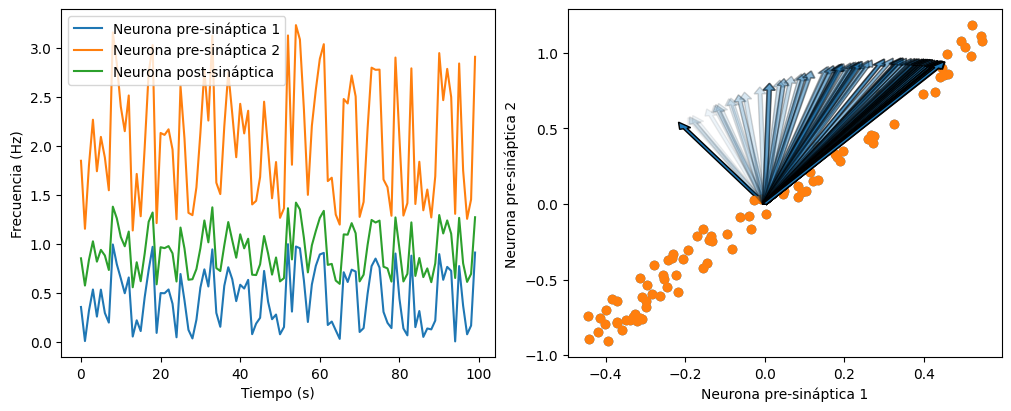

In [11]:
# Valor inicial de los pesos sinápticos
w = np.array([-0.2, 0.5])

z = x - np.mean(x, axis=0)

# Graficamos los puntos
plt.scatter(z[:,0], z[:,1])

eta = 0.1

for i in range(n):
  # Actividad de la neurona pre-sináptica 1
  ri = z[i][0]

  # Actividad de la neurona pre-sináptica 2
  rj = z[i][1]

  # Actividad de la neurona post-sináptica con en este instante temporal
  rPost = ri * w[0] + rj * w[1]

  # Actualizamos los pesos según la regla de Oja
  w[0] = w[0] + eta * (rPost * ri - (rPost ** 2) * w[0])
  w[1] = w[1] + eta * (rPost * rj - (rPost ** 2) * w[1])

  # Graficamos una flecha con los pesos
  plt.arrow(0, 0, w[0].item(), w[1].item(), width=0.01, alpha=i/n)